In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle

In [2]:
## Importing the data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
air = pd.read_csv(url)

In [3]:
air.shape

(144, 2)

In [18]:
air.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
## Time based column( date, month, quarter, year, hours) must be the index of your dataset
air['Month'] = pd.to_datetime(air['Month'])
air.set_index('Month', inplace= True)

In [5]:
air.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [7]:
#### MS(Month start) implies we are taking the data at the beginning of every month
#### ME(Month end) implies taking data at the end of every month
#### air.asfreq("ME")
#### air.asfreq("M") implies monthly but python interpretes it as Month End(ME)
air = air.asfreq("MS")

In [8]:
air.isna().sum()

Passengers    0
dtype: int64

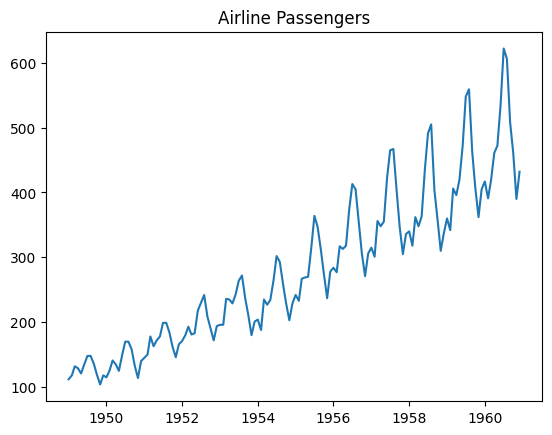

In [23]:
## Ploting the original dataset for visualization
plt.plot(air)
plt.title('Airline Passengers')
plt.show()

In [24]:
y = air["Passengers"]

## Test for Stationarity (ADF)
### Hypothesis
- H0: The series is non-stationary
- H1: The series is stationary

In [25]:
#### test for stationarity
result = adfuller(y)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060472
p-value: 0.991880243437641


- Since p-value > 0.05, we will fail to reject the Null hypothesis. This means the series is non-stationary

In [9]:
## Differentianting the time series dataset for data to be stationary
air_diff = air.diff()
air_diff.head()

,Passengers
Month,
1949-01-01,NaN
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0


In [10]:
## Drop missing value
air_diff.dropna(inplace = True)
air_diff.head()

,Passengers
Month,
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
1949-06-01,14.0


In [13]:
y = air_diff["Passengers"]

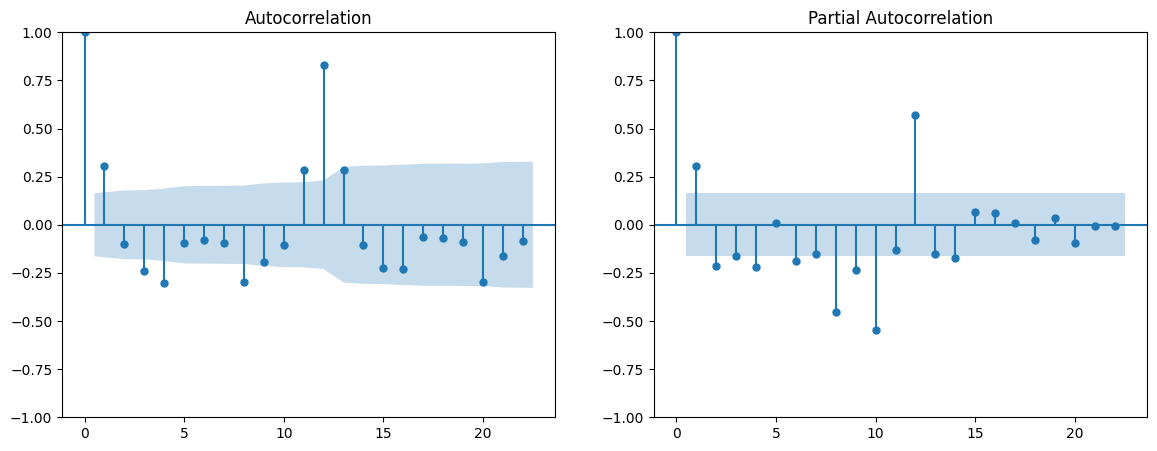

In [14]:
#### plot ACF(q) and PACF(p)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(y, ax=axes[0])
plot_pacf(y, ax=axes[1])

plt.show()

In [15]:
#### Train and test split
train_size = int(len(y) * 0.8)

train = y[:train_size]
test = y[train_size:]

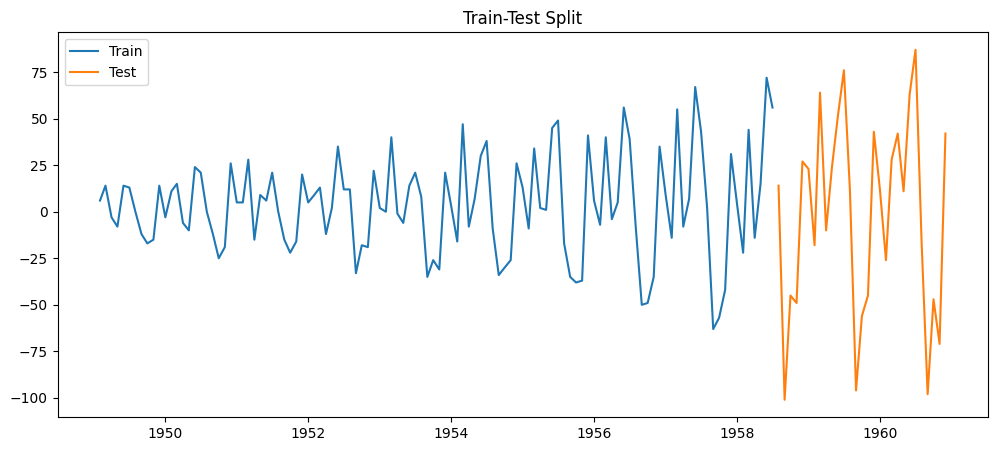

In [16]:
#### plot the train and test data
plt.figure(figsize=(12,5))

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.legend()
plt.title("Train-Test Split")
plt.show()

In [17]:
# Initializing the ARIMA model
model = ARIMA(train, order= (3,1,2))

## Fitting the model to the dataset
result = model.fit()

C:\Users\Blossom Academy\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [18]:
### use the model for prediction
forecast  = result.forecast(steps = len(test))

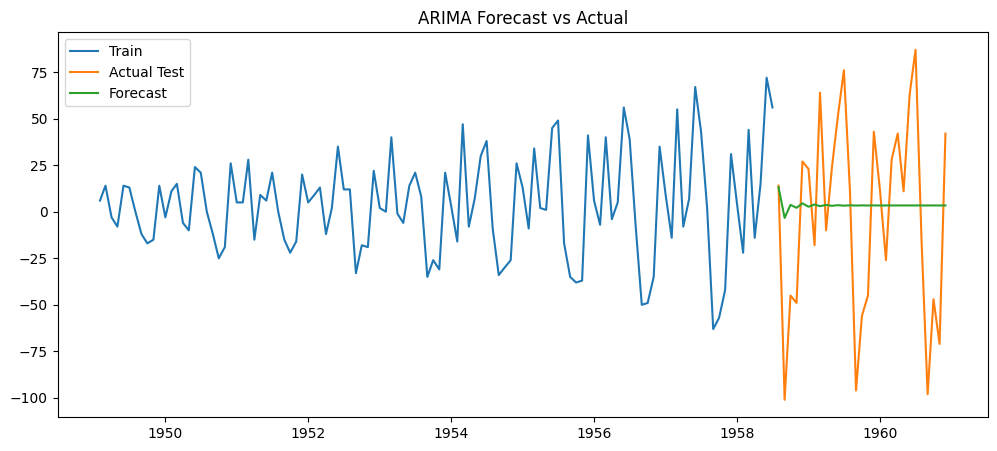

In [19]:
#### plot of predicted and actual (train and test)

plt.figure(figsize=(12,5))

plt.plot(train, label='Train')
plt.plot(test, label='Actual Test')
plt.plot(forecast, label='Forecast')

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [20]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 43.79924770923701
RMSE: 52.23233010775838


### Time Series Analysis using Prophet

In [21]:
#pip install prophet

In [22]:
from prophet import Prophet

In [23]:
## importing the passneger data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [24]:
df.columns = ['ds', 'y']

#Changing the ds column to be in date format
df['ds'] = pd.to_datetime(df['ds'])
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [25]:
#### Train and test split
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

In [26]:
## Initialize the model and fit 

model_prophet = Prophet()
model_prophet = model_prophet.fit(train)

15:22:00 - cmdstanpy - INFO - Chain [1] start processing
15:22:00 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
future = test[['ds']]
forecast = model_prophet.predict(future)

In [30]:
forecast.head(2)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1958-08-01,400.786587,425.564731,469.183362,400.785541,400.787926,47.272089,47.272089,47.272089,47.272089,47.272089,47.272089,0.0,0.0,0.0,448.058676
1,1958-09-01,403.926914,395.289172,438.853060,403.903190,403.955095,14.264581,14.264581,14.264581,14.264581,14.264581,14.264581,0.0,0.0,0.0,418.191495


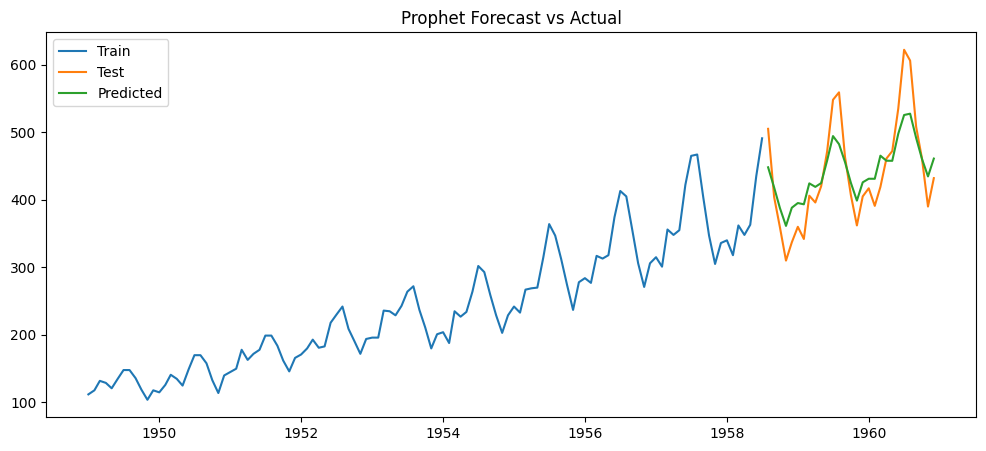

In [32]:
plt.figure(figsize=(12,5))

# Train data
plt.plot(train['ds'], train['y'], label='Train')

# Test data
plt.plot(test['ds'], test['y'], label='Test')

# Predicted values
plt.plot(test['ds'], forecast['yhat'], label='Predicted')

plt.legend()
plt.title("Prophet Forecast vs Actual")
plt.show()

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['y'], forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast['yhat']))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 33.89631463022029
RMSE: 41.33248923380606


#### Create our own future date

In [38]:
## Specifying the future time series to be forecasted
future = model_prophet.make_future_dataframe(periods= 12, freq= 'MS')
future.tail(20)

,ds
107,1957-12-01
108,1958-01-01
109,1958-02-01
110,1958-03-01
111,1958-04-01
112,1958-05-01
113,1958-06-01
114,1958-07-01
115,1958-08-01
116,1958-09-01


In [41]:
## Making predictions for the future time frame
forecast_pro = model_prophet.predict(future)
forecast_pro[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
115,1958-08-01,448.058676,425.449501,472.044844
116,1958-09-01,418.191495,395.615651,439.933927
117,1958-10-01,387.550900,364.016551,408.921767
118,1958-11-01,361.356610,341.023925,383.351592
119,1958-12-01,388.238044,366.922772,410.230980
120,1959-01-01,395.163590,372.358791,416.712770
121,1959-02-01,393.295905,371.712960,415.241207
122,1959-03-01,424.312156,400.558935,446.676062
123,1959-04-01,419.093762,397.435961,443.438661
124,1959-05-01,424.705836,404.149544,446.903760


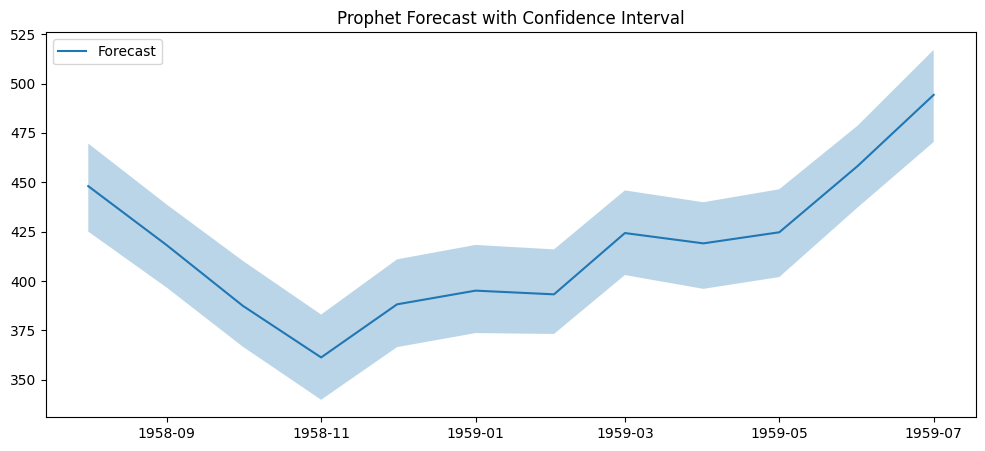

In [78]:
plt.figure(figsize=(12,5))

# Predicted line
plt.plot(
    forecast_pro['ds'].tail(12),
    forecast_pro['yhat'].tail(12),
    label='Forecast'
)

# Confidence interval
plt.fill_between(
    forecast_pro['ds'].tail(12),
    forecast_pro['yhat_lower'].tail(12),
    forecast_pro['yhat_upper'].tail(12),
    alpha=0.3
)

plt.legend()
plt.title("Prophet Forecast with Confidence Interval")

plt.show()